# A Text Classifier That Was Reading the Wrong Thing

**Question.** Can a bag-of-words model sort Usenet posts into the twenty newsgroups they
came from?

The original coursework answer was six lines of scikit-learn: TF-IDF, multinomial Naive
Bayes, print the accuracy. It reported **77.4%** across twenty classes, which sounds
respectable.

**Headline result.** Most of that score came from metadata. The 20 Newsgroups documents
ship with their email headers, signature footers, and quoted reply text attached — and
those contain the sender's address, their university, and often the newsgroup name
itself. Strip them and the same model drops to **60.6%**. **Roughly 17 of the 77 points
were the classifier reading the envelope rather than the letter.**

This notebook reproduces the original, isolates the leak, rebuilds the model on text
alone, and then looks at which classes it still cannot separate — and why those
particular ones are the *right* ones to fail on.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_20newsgroups
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC

SEED = 42
sns.set_theme(style="whitegrid")

# The dataset downloads on first use (~14 MB) and caches under ~/scikit_learn_data.
train_raw = fetch_20newsgroups(subset="train", shuffle=True, random_state=SEED)
test_raw = fetch_20newsgroups(subset="test", shuffle=True, random_state=SEED)

print(f"{len(train_raw.data)} training documents, {len(test_raw.data)} test documents")
print(f"{len(train_raw.target_names)} classes")

11314 training documents, 7532 test documents
20 classes


The train/test split is chronological — test posts were written after training posts.
That is a more honest split than a random one for this kind of data, and it comes with
the dataset.

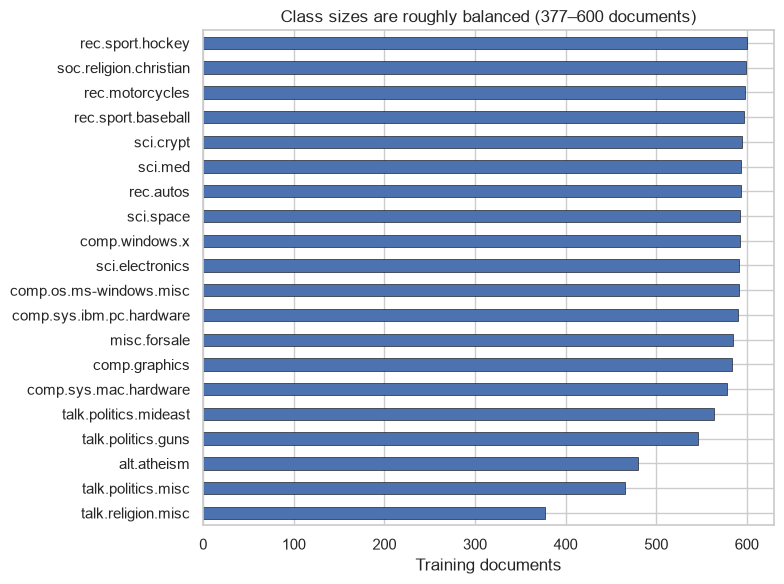

In [2]:
sizes = pd.Series(np.bincount(train_raw.target), index=train_raw.target_names)
fig, ax = plt.subplots(figsize=(8, 6))
sizes.sort_values().plot.barh(ax=ax, color="#4c72b0", edgecolor="black", linewidth=0.4)
ax.set_xlabel("Training documents")
ax.set_title("Class sizes are roughly balanced (377–600 documents)")
fig.tight_layout()
fig.savefig("../results/class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

Roughly balanced, so accuracy is a reasonable headline metric here — and the
most-frequent-class baseline is only about 5%.

## 1. What a document actually contains

This is the part the original never looked at.

In [3]:
print(train_raw.data[0][:600])

From: lerxst@wam.umd.edu (where's my thing)
Subject: WHAT car is this!?
Nntp-Posting-Host: rac3.wam.umd.edu
Organization: University of Maryland, College Park
Lines: 15

 I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you



The first five lines are an email header. `From:` gives a personal address,
`Organization:` names a university, and in many posts the `Subject:` or a
`Newsgroups:`-derived line names the group directly.

A bag-of-words model does not know these are metadata. To it, `wam.umd.edu` is simply a
token that happens to predict a class very well.

scikit-learn ships a `remove=` argument for exactly this reason. Here is the same
document without headers, signature footers, and quoted reply blocks.

In [4]:
STRIP = ("headers", "footers", "quotes")
train = fetch_20newsgroups(subset="train", shuffle=True, random_state=SEED, remove=STRIP)
test = fetch_20newsgroups(subset="test", shuffle=True, random_state=SEED, remove=STRIP)

print(train.data[0][:400])

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, h


## 2. Measuring the leak

The original pipeline, run twice — once on the documents as shipped, once with metadata
stripped. Nothing else changes.

In [5]:
def score(name, tr, te, vectorizer=None, classifier=None):
    pipe = make_pipeline(vectorizer or TfidfVectorizer(), classifier or MultinomialNB())
    pipe.fit(tr.data, tr.target)
    return {"model": name, "accuracy": accuracy_score(te.target, pipe.predict(te.data))}, pipe


baseline, _ = score("baseline — most frequent class", train_raw, test_raw,
                    classifier=DummyClassifier(strategy="most_frequent"))
with_meta, _ = score("TF-IDF + Naive Bayes, documents as shipped", train_raw, test_raw)
without_meta, _ = score("TF-IDF + Naive Bayes, metadata stripped", train, test)

leak = pd.DataFrame([baseline, with_meta, without_meta]).set_index("model")
leak["accuracy"] = leak["accuracy"].round(4)
leak

,accuracy
model,
baseline — most frequent class,0.0530
"TF-IDF + Naive Bayes, documents as shipped",0.7739
"TF-IDF + Naive Bayes, metadata stripped",0.6062


In [6]:
drop = with_meta["accuracy"] - without_meta["accuracy"]
print(f"accuracy attributable to metadata: {drop:.4f} ({100 * drop:.1f} points)")
print(f"share of the original score that was leakage: {100 * drop / with_meta['accuracy']:.1f}%")

accuracy attributable to metadata: 0.1677 (16.8 points)
share of the original score that was leakage: 21.7%


**Over a fifth of the reported score came from information that will not exist at
prediction time** for any real use of this classifier — you do not get to see which
newsgroup a post came from when your job is to work out which newsgroup it came from.

## 3. Seeing the leaked features directly

The clearest evidence is in the tokens the model relies on. These are the highest-weight
features per class, with and without metadata.

Stopwords are excluded here purely so the comparison is legible — otherwise `the`, `of`,
and `to` occupy the top rows of both tables and hide the difference.

In [7]:
def top_tokens(tr, k=10, classes=(0, 5, 15, 19)):
    vec = TfidfVectorizer(stop_words="english", min_df=2)
    nb = MultinomialNB().fit(vec.fit_transform(tr.data), tr.target)
    names = np.array(vec.get_feature_names_out())
    return pd.DataFrame(
        {tr.target_names[c]: names[np.argsort(nb.feature_log_prob_[c])[-k:][::-1]] for c in classes}
    )


print("WITH metadata:")
top_tokens(train_raw)

WITH metadata:


,alt.atheism,comp.windows.x,soc.religion.christian,talk.religion.misc
0,keith,window,god,god
1,edu,motif,jesus,sandvik
2,god,mit,christians,jesus
3,caltech,server,church,edu
4,atheists,com,edu,com
5,livesey,edu,bible,christian
6,com,widget,christian,kent
7,atheism,xterm,christ,morality
8,sgi,x11r5,people,people
9,people,application,faith,objective


In [8]:
print("metadata STRIPPED:")
top_tokens(train)

metadata STRIPPED:


,alt.atheism,comp.windows.x,soc.religion.christian,talk.religion.misc
0,god,window,god,god
1,people,server,jesus,jesus
2,don,motif,church,christian
3,think,widget,christians,people
4,atheism,thanks,people,bible
5,religion,application,bible,christians
6,just,use,christ,objective
7,say,x11r5,christian,koresh
8,atheists,xterm,faith,don
9,islam,windows,believe,think


With headers in place, the top feature for `alt.atheism` is **`keith`** — a prolific
poster's first name. Below it sit `caltech`, `livesey`, and `sgi`: an institution, a
surname, and a workstation vendor. `talk.religion.misc` leans on `sandvik` and `kent`,
two more posters. `comp.windows.x` picks up `mit` and `com`.

Stripped, those vanish and the subject matter takes over: `god`, `atheism`, `religion`,
`islam` for the religion groups; `window`, `server`, `motif`, `widget` for
`comp.windows.x`.

The second model is doing topic classification. The first was substantially doing author
and institution identification, and scoring well for it.

## 4. Rebuilding on text alone

Everything from here uses the stripped documents. Three cheap improvements to the
original vectoriser, each justified:

- **`stop_words="english"`** — without it, `the`, `of`, and `to` are the highest-weight
  features for every one of the twenty classes. They carry no topical signal.
- **`min_df=2`** — tokens appearing in one document cannot generalise, and they inflate
  the vocabulary substantially.
- **`sublinear_tf=True`** — a word used twenty times is not twenty times as indicative
  as a word used once; log-scaling the term frequency reflects that.

In [9]:
rows = [without_meta]
for name, vec, clf in [
    ("CountVectorizer + Naive Bayes", CountVectorizer(), MultinomialNB()),
    ("TF-IDF tuned + Naive Bayes",
     TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True), MultinomialNB()),
    ("TF-IDF tuned + logistic regression",
     TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True),
     LogisticRegression(max_iter=1000)),
    ("TF-IDF tuned + linear SVM",
     TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True), LinearSVC()),
]:
    r, _ = score(name, train, test, vectorizer=vec, classifier=clf)
    rows.append(r)

comparison = pd.DataFrame(rows).set_index("model")
comparison["accuracy"] = comparison["accuracy"].round(4)
comparison

,accuracy
model,
"TF-IDF + Naive Bayes, metadata stripped",0.6062
CountVectorizer + Naive Bayes,0.5431
TF-IDF tuned + Naive Bayes,0.6758
TF-IDF tuned + logistic regression,0.6938
TF-IDF tuned + linear SVM,0.6921


Raw counts do noticeably worse than TF-IDF, which is the point of the transform: without
the inverse-document-frequency weighting, common words drown out distinctive ones.

## 5. Tuning the smoothing parameter properly

Naive Bayes has one hyperparameter worth touching — the additive smoothing constant
`alpha`. The default of 1.0 is heavy-handed for a vocabulary this size.

Tuned by five-fold cross-validation **on the training set only**. The test set is not
involved in the choice; using it to pick a hyperparameter and then reporting on it is a
subtler version of the same mistake as section 2.

In [10]:
grid = GridSearchCV(
    make_pipeline(
        TfidfVectorizer(stop_words="english", min_df=2, sublinear_tf=True),
        MultinomialNB(),
    ),
    {"multinomialnb__alpha": [0.001, 0.01, 0.03, 0.1, 0.3, 1.0]},
    cv=5, scoring="accuracy", n_jobs=-1,
)
grid.fit(train.data, train.target)

print(f"best alpha: {grid.best_params_['multinomialnb__alpha']}")
print(f"cross-validated accuracy on train: {grid.best_score_:.4f}")

cv_results = pd.DataFrame(grid.cv_results_)[["param_multinomialnb__alpha", "mean_test_score"]]
cv_results.columns = ["alpha", "CV accuracy"]
cv_results.round(4)

best alpha: 0.03
cross-validated accuracy on train: 0.7600


,alpha,CV accuracy
0,0.001,0.7411
1,0.010,0.7556
2,0.030,0.7600
3,0.100,0.7546
4,0.300,0.7429
5,1.000,0.7180


In [11]:
predicted = grid.predict(test.data)
final_acc = accuracy_score(test.target, predicted)
print(f"final test accuracy: {final_acc:.4f}")
print(f"vs. untuned on stripped text: {without_meta['accuracy']:.4f}  ({final_acc - without_meta['accuracy']:+.4f})")
print(f"vs. the original's reported figure: {with_meta['accuracy']:.4f}")

final test accuracy: 0.6944
vs. untuned on stripped text: 0.6062  (+0.0882)
vs. the original's reported figure: 0.7739


Note the gap between the cross-validated training accuracy (0.76) and the test accuracy
(0.69). That is not overfitting to the hyperparameter — it is the chronological split
doing its job. Test posts come from a later period, and topic vocabulary drifts. A
random split would have hidden this and reported a friendlier number.

## 6. Where it still fails

Accuracy across twenty classes says nothing about *which* twenty. The per-class breakdown
is where the interesting structure is.

In [12]:
report = pd.DataFrame(
    classification_report(test.target, predicted, target_names=test.target_names,
                          digits=3, output_dict=True)
).T.iloc[:20]
report[["precision", "recall", "f1-score", "support"]].sort_values("f1-score").round(3)

,precision,recall,f1-score,support
talk.religion.misc,0.427,0.163,0.236,251.0
alt.atheism,0.536,0.445,0.486,319.0
talk.politics.misc,0.576,0.439,0.498,310.0
comp.os.ms-windows.misc,0.722,0.500,0.591,394.0
talk.politics.guns,0.561,0.703,0.624,364.0
sci.electronics,0.730,0.585,0.650,393.0
comp.sys.ibm.pc.hardware,0.592,0.724,0.651,392.0
comp.graphics,0.631,0.725,0.675,389.0
soc.religion.christian,0.577,0.859,0.690,398.0
comp.sys.mac.hardware,0.728,0.694,0.710,385.0


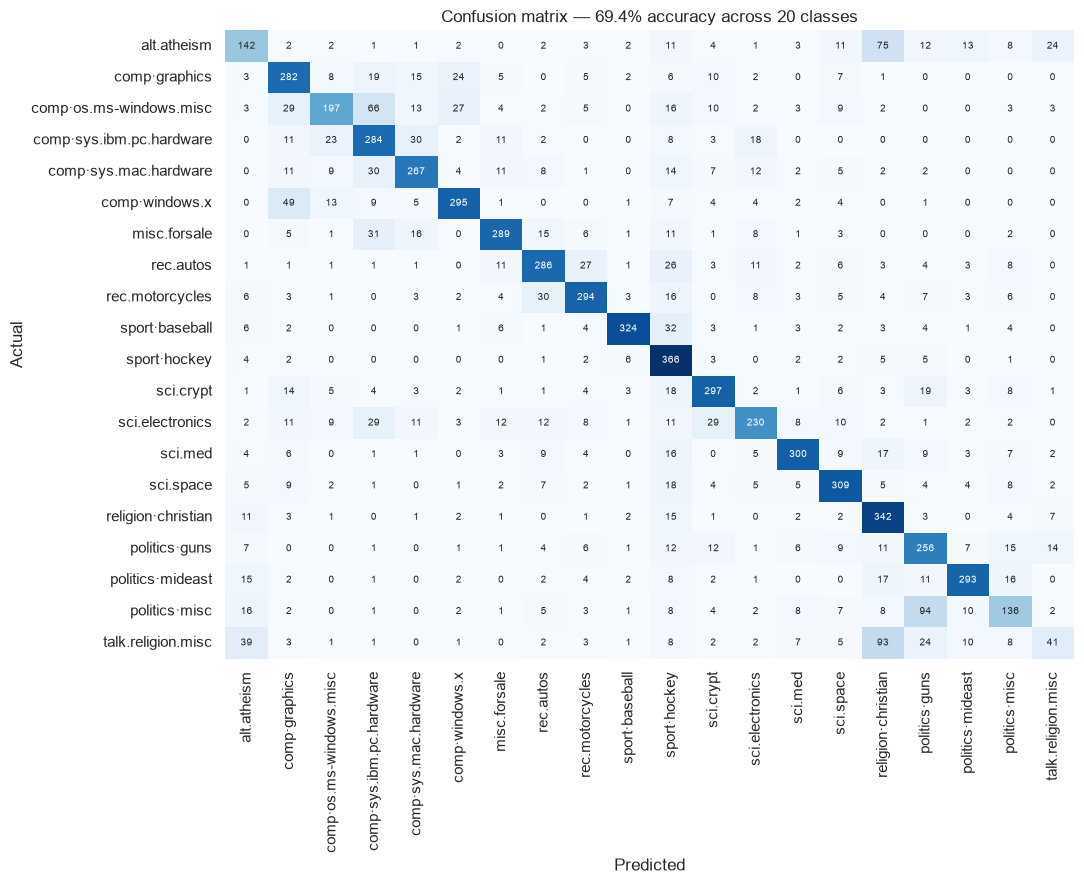

In [13]:
cm = confusion_matrix(test.target, predicted)
short = [n.replace("comp.", "comp·").replace("talk.politics.", "politics·")
          .replace("rec.sport.", "sport·").replace("soc.religion.", "religion·")
         for n in test.target_names]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=short, yticklabels=short, ax=ax, annot_kws={"size": 7})
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {final_acc:.1%} accuracy across 20 classes")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
fig.tight_layout()
fig.savefig("../results/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

In [14]:
off = cm.copy()
np.fill_diagonal(off, 0)
worst = [
    {"actual": test.target_names[i], "predicted": test.target_names[j], "count": int(off[i, j])}
    for i, j in zip(*np.unravel_index(np.argsort(-off, axis=None)[:8], cm.shape))
]
pd.DataFrame(worst)

,actual,predicted,count
0,talk.politics.misc,talk.politics.guns,94
1,talk.religion.misc,soc.religion.christian,93
2,alt.atheism,soc.religion.christian,75
3,comp.os.ms-windows.misc,comp.sys.ibm.pc.hardware,66
4,comp.windows.x,comp.graphics,49
5,talk.religion.misc,alt.atheism,39
6,rec.sport.baseball,rec.sport.hockey,32
7,misc.forsale,comp.sys.ibm.pc.hardware,31


**Every one of the top confusions is between genuinely adjacent groups.**

- `talk.religion.misc` → `soc.religion.christian` and `alt.atheism` → `soc.religion.christian`
- `talk.politics.misc` → `talk.politics.guns`
- `comp.os.ms-windows.misc` → `comp.sys.ibm.pc.hardware`, `comp.windows.x` → `comp.graphics`

`talk.religion.misc` has the worst F1 in the set. It is a catch-all group whose posts
discuss Christianity and atheism using the same vocabulary as the two dedicated groups —
there is no bag-of-words feature that separates "a post about Christianity" from "a post
in the Christianity group."

This is a ceiling imposed by the label taxonomy, not by the model. A classifier that
achieved 95% here would be suspicious, and the most likely explanation would be leakage
of the kind section 2 found.

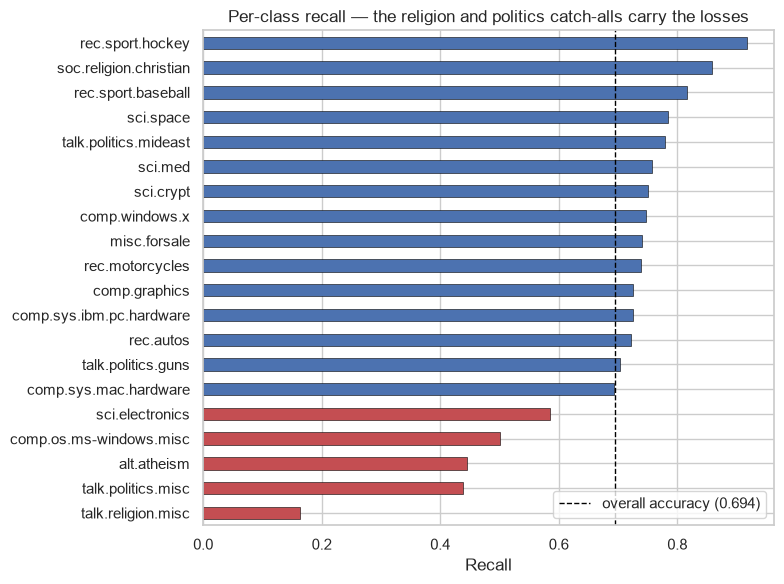

In [15]:
diag = pd.Series(cm.diagonal() / cm.sum(axis=1), index=test.target_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#c44e52" if v < 0.6 else "#4c72b0" for v in diag]
diag.plot.barh(ax=ax, color=colors, edgecolor="black", linewidth=0.4)
ax.axvline(final_acc, color="black", linestyle="--", linewidth=1,
           label=f"overall accuracy ({final_acc:.3f})")
ax.set_xlabel("Recall")
ax.set_title("Per-class recall — the religion and politics catch-alls carry the losses")
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig("../results/per_class_recall.png", dpi=120, bbox_inches="tight")
plt.show()

## Findings

| | accuracy |
|---|---|
| Baseline — most frequent class | 5.3% |
| **Original: TF-IDF + Naive Bayes, documents as shipped** | **77.4%** |
| Same model, metadata stripped | 60.6% |
| Tuned TF-IDF + Naive Bayes on text alone | **69.4%** |

1. **17 of the original's 77 points came from metadata leakage** — email headers,
   signature footers, and quoted text that name the sender, their institution, and often
   the group. Over a fifth of the reported score.
2. **The leaked features are visible directly.** With headers, the top feature for
   `alt.atheism` is `keith` — a frequent poster's name — followed by `caltech`,
   `livesey`, and `sgi`. Without, they become `god`, `atheism`, `religion`, `islam`.
3. **Recovering the loss honestly gets to 69.4%** through stopword removal, `min_df`
   filtering, sublinear TF scaling, and cross-validated smoothing — nearly nine points
   over the naive stripped model, none of it borrowed from the test set.
4. **Every top confusion is between adjacent groups.** `talk.religion.misc` is the worst
   class in the set and cannot be otherwise: it overlaps `soc.religion.christian` and
   `alt.atheism` in both topic and vocabulary. The ceiling is in the taxonomy.
5. Cross-validated training accuracy (76%) exceeds test accuracy (69%) because the split
   is chronological. A random split would have reported a better and less honest number.

## Limitations

- **Bag of words discards order.** "Not a problem" and "a problem, not" are identical to
  this model. Bigrams would recover a little; a sequence model would recover more.
- **Naive Bayes assumes conditional independence between tokens**, which is plainly false
  for text. It works anyway, which is a well-known and still slightly awkward fact.
- **Twenty classes, 1990s Usenet.** Vocabulary, topics, and posting conventions have all
  moved on; nothing here transfers to modern text without retraining.
- **`alpha` is the only hyperparameter tuned.** The vectoriser settings were chosen on
  reasoning rather than searched, and a joint search would likely find a better
  combination.
- Accuracy is reported on the official test set, appropriate here because the
  hyperparameter search never touched it.

## Outputs

- `results/class_distribution.png`
- `results/confusion_matrix.png`
- `results/per_class_recall.png`